### Since our goal is visual pattern extraction,
- We need to convert SVGs to raster images, 
- PNG are great because it allows lossless compression, so no data will be lost in compression.



We will use cairosvg library to convert SVGs to PNGs

- What things we need to consider when conversion:
- Raster images must be small as possible in size (height and width)
- Same size for all images
- Maintain all information of Kanji storkes (Let's find the kanji with most strokes and convert it and see if it looks good enough in PNG)



In the Jouyou list,
# 鑑 (かん)
kanji has the most strokes.
- Let's take this as example and try converting the image.

In [1]:
kan_file_path = '../data_cleaned/jouyou_kanji/09451.svg'

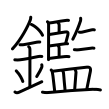

'../data_cleaned/jouyou_kanji/09451.svg'

In [20]:
from IPython.display import SVG, display
display(SVG(filename=kan_file_path))

In [17]:
import cairosvg

test_output_url = "../data_cleaned/test_outputs/09451.png"

cairosvg.svg2png(url=kan_file_path, write_to=test_output_url)

In [22]:
from PIL import Image

converted_image = Image.open(test_output_url)
converted_image.size

(109, 109)

Alright, works well!
All strokes are clearly visible in 109 x 109 size
Let's convert all the images

In [82]:
jouyou_kanji_raster_folder_path = "../data_cleaned/jouyou_kanji_raster"
all_kanji_raster_folder_path = "../data_cleaned/all_kanji_raster"

output_paths = [jouyou_kanji_raster_folder_path, all_kanji_raster_folder_path]

jouyou_kanji_path = '../data_cleaned/jouyou_kanji/'
kanji_all_path = '../data_cleaned/kanji_all'

input_paths = [jouyou_kanji_path, kanji_all_path]

In [83]:
import shutil
import os
import sys

# create folders if already exists delete first
for path in output_paths:
  if os.path.exists(path):
    shutil.rmtree(path)

  os.makedirs(path)

In [85]:
paths = zip(input_paths, output_paths)

# convert all svgs to pngs
for (input_path, output_path) in paths:
  file_names = os.listdir(input_path)

  print(f'\nStarting to process {input_path} -> {output_path}')

  total = len(file_names)
  processed = 0

  for file_name in file_names:
    processed += 1

    file_name_without_extension = file_name.split('.')[0]

    sys.stdout.write(f"\rProcessing... {int((processed / total) * 100)}%, remaining: {processed}/{total}")
    sys.stdout.flush()

    full_path_input = os.path.join(input_path, file_name)
    full_path_output = os.path.join(output_path, file_name_without_extension + '.png')

    if os.path.exists(full_path_output):
      os.remove(full_path_output)
    
    cairosvg.svg2png(url=full_path_input, write_to=full_path_output, output_width=108, output_height=108)
    


Starting to process ../data_cleaned/jouyou_kanji/ -> ../data_cleaned/jouyou_kanji_raster
Processing... 100%, remaining: 2136/2136
Starting to process ../data_cleaned/kanji_all -> ../data_cleaned/all_kanji_raster
Processing... 100%, remaining: 11658/11658